In [49]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [51]:
transform_op = transforms.Compose([transforms.ToTensor()])

In [52]:
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform_op)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform_op)

In [53]:
# define variables
num_classes = 10
batch_size = 64
num_channels = 1 # grayscale
img_size = 28
patch_size = 7 # 4
num_patches = (img_size // patch_size) ** 2
embedding_size = 64 # 1 patch -> 1 vector
mlp_hidden_nodes = 128
attention_heads = 4
transformer_blocks = 4
learning_rate = 0.001
epochs = 5

In [54]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [55]:
# 1. Patch Embedding
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = nn.Conv2d(num_channels, embedding_size, kernel_size=patch_size, stride=patch_size) # no trainable params

  def forward(self, x):
    # x.shape is (64, 1, 28, 28) (batch, channels, height, width)
    x = self.patch_embedding(x) # (64, 64, 4, 4) (batch, embedding_size/channels, patch_rows, patch_cols)
    # flatten the last 2 dims (4 x 4)
    x = x.flatten(2) # (64, 64, 16)
    x = x.transpose(1, 2) # (64, 16, 64) (64 images, 16 patches per image, 64-dim embedding for each patch)
    return x
    # [CLASS] and positional embedding

In [56]:
# check shapes of PatchEmbedding
data_point, label = next(iter(train_loader))
print(f"Input image shape: {data_point.shape}")

# Instantiate PatchEmbedding and move it to the device for correct shape checking
temp_patch_embed_module = PatchEmbedding().to(device)
patch_embedding_output = temp_patch_embed_module(data_point.to(device))
print(f"Output shape after PatchEmbedding: {patch_embedding_output.shape}")
# Expected output shape: (batch_size, num_patches, embedding_size)
# e.g., (64, 16, 64) with current parameters.

Input image shape: torch.Size([64, 1, 28, 28])
Output shape after PatchEmbedding: torch.Size([64, 16, 64])


In [57]:
# 2. Encoder
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(embedding_size)
    self.layer_norm_2 = nn.LayerNorm(embedding_size)
    self.multi_head_attn = nn.MultiheadAttention(embed_dim=embedding_size, num_heads=attention_heads, batch_first=True)
    self.mlp = nn.Sequential(
        nn.Linear(embedding_size, mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes, embedding_size)
    )

  def forward(self, x):
    residual_1 = x
    x = self.layer_norm_1(x)
    x = self.multi_head_attn(x, x, x)[0]
    x = x + residual_1

    residual_2 = x
    x = self.layer_norm_2(x)
    x = self.mlp(x)
    x = x + residual_2

    return x

In [58]:
# 3. MLP Head
class MLPHead(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(embedding_size)
    self.mlp_head = nn.Linear(embedding_size, num_classes)

  def forward(self, x):
    x = self.layer_norm_1(x)
    x = self.mlp_head(x)
    return x

In [59]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_size)) # (1 batch, 1 cls token, embedding_size)
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_size))
    self.transformer_blocks = nn.Sequential(*[Encoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLPHead()

  def forward(self, x):
    # x: (batch_size, num_channels, img_size, img_size) example: (64, 1, 28, 28)
    x = self.patch_embedding(x) # (batch_size, num_patches, embedding_size) (64, 16, 64)
    B = x.size(0) # current batch size
    class_tokens = self.cls_token.expand(B, -1, -1)
    x = torch.cat((class_tokens, x), dim=1)
    x = x + self.position_embedding
    x = self.transformer_blocks(x)
    x = x[:, 0] # pick the cls token from every batch
    x = self.mlp_head(x)
    return x

In [60]:
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [61]:
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # -------------------- Training --------------------
    model.train()
    total_loss, total_correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = 100 * total_correct / total

    # Save metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------------------- Testing --------------------
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_acc = 100 * test_correct / test_total
    test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )

Epoch [1/5] | Train Loss: 0.3725 | Train Acc: 88.08% | Test Acc: 94.90%
Epoch [2/5] | Train Loss: 0.1224 | Train Acc: 96.22% | Test Acc: 96.32%
Epoch [3/5] | Train Loss: 0.0921 | Train Acc: 97.12% | Test Acc: 97.08%
Epoch [4/5] | Train Loss: 0.0747 | Train Acc: 97.69% | Test Acc: 96.93%
Epoch [5/5] | Train Loss: 0.0645 | Train Acc: 97.88% | Test Acc: 97.51%


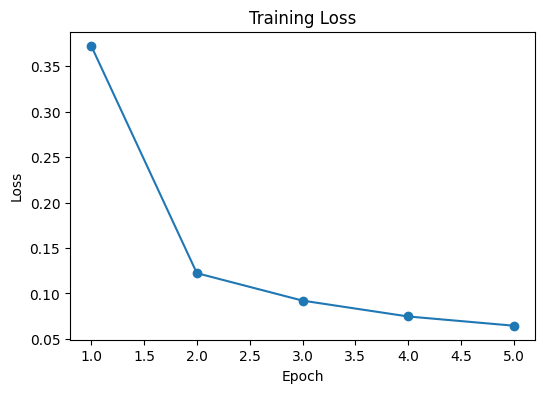

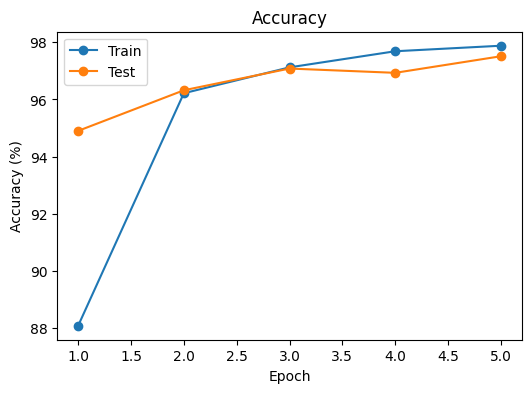

In [67]:
# Plot training loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot accuracies
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o", label="Train")
plt.plot(range(1, epochs + 1), test_accuracies, marker="o", label="Test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

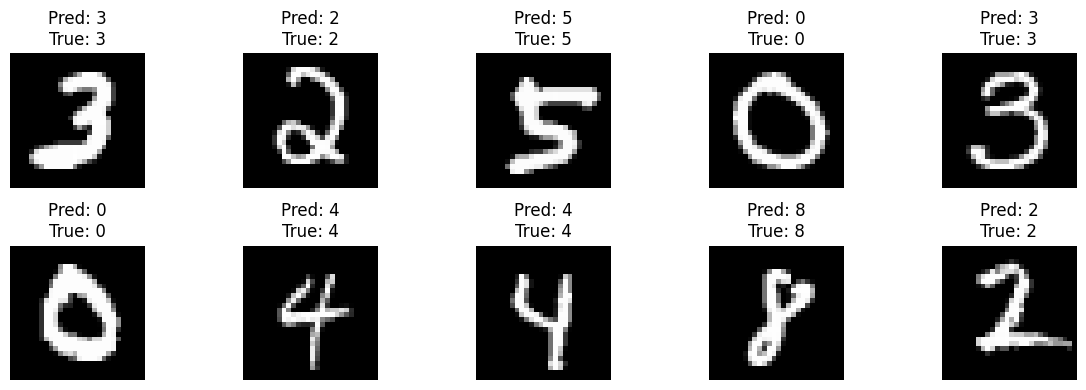

In [63]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1)

# move to cpu for plotting
images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# plot images
plt.figure(figsize=(12, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i].squeeze(), cmap="gray")
  plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
  plt.axis("off")
plt.tight_layout()
plt.show()